# Number of Repair Crews vs Trade-off Index

This notebook plots the **Trade-off Index (TOI)** of the objective-function pairs as a function of the **number of repair crews**.

The input Excel file contains, for each number of crews:

- Trade-off Index (%) for the 15 objective-function pairs
- Pearson's correlation coefficient (`r`) for the same pairs

Only the **Trade-off Index (%)** rows are used for this figure.

The resulting plot has:

- **X-axis:** Number of repair crews
- **Y-axis:** Trade-off Index (%)
- **Lines:** Objective-function pairs


## 1. Import libraries

In [25]:
import pandas as pd
import matplotlib.pyplot as plt


In [26]:
# Damage scenario to analyse
ds_sel = 'DS4'

## 2. Import the Excel file

Change `file_name` if you want to analyse a different damage scenario or dataset.

In [ ]:
# IMPORT DATA

file_name = f"TOI_and_R_results_{ds_sel}_total.xlsx"

df = pd.read_excel(file_name)

print(f"File loaded: {file_name}")
print(f"Data shape: {df.shape}")

df.head()


File loaded: TOI_and_R_results_DS4_total.xlsx
Data shape: (12, 17)


,Crews,Metric,FH - t95,FH - RL,FH - TNS,FH - NWSECH,FH - WL,t95 - RL,t95 - TNS,t95 - NWSECH,t95 - WL,RL - TNS,RL - NWSECH,RL - WL,TNS - NWSECH,TNS - WL,NWSECH - WL
0,1,Trade-off Index (%),36.988,54.278,29.826,43.255,69.079,25.893,37.248,44.680,33.117,33.143,60.988,37.327,46.410,56.943,68.454
1,1,Pearson's r,0.071,-0.157,0.464,0.263,-0.513,0.259,0.036,-0.087,0.170,0.657,-0.342,0.535,-0.022,0.110,-0.509
2,3,Trade-off Index (%),37.675,54.606,33.809,49.340,64.349,10.472,54.124,39.567,12.769,60.655,55.860,24.090,50.142,75.634,61.039
3,3,Pearson's r,-0.130,-0.196,0.424,0.095,-0.314,0.854,-0.775,-0.245,0.900,-0.630,-0.273,0.901,0.080,-0.836,-0.299
4,8,Trade-off Index (%),50.718,64.339,28.298,48.362,72.036,21.600,62.695,42.728,4.320,55.875,49.002,30.228,39.708,79.350,58.147


## 3. Identify the objective-function pairs

The objective-function pair columns are detected automatically, so the notebook does not need to be modified if the order of the pairs changes.

In [ ]:
# IDENTIFY OBJECTIVE-FUNCTION PAIRS

# Columns that identify the rows
id_columns = ["Crews", "Metric"]

# All remaining columns are objective-function pairs
pair_columns = [col for col in df.columns if col not in id_columns]

print(f"Number of objective-function pairs: {len(pair_columns)}")
print("\nObjective-function pairs:")
for pair in pair_columns:
    print(f"- {pair}")


Number of objective-function pairs: 15

Objective-function pairs:
- FH - t95
- FH - RL
- FH - TNS
- FH - NWSECH
- FH - WL
- t95 - RL
- t95 - TNS
- t95 - NWSECH
- t95 - WL
- RL - TNS
- RL - NWSECH
- RL - WL
- TNS - NWSECH
- TNS - WL
- NWSECH - WL


## 4. Select the objective-function pairs to plot

By default, the notebook plots **all objective-function pairs**.

If the figure becomes too crowded, you can select only specific pairs, for example:

```python
selected_pairs = [
    "FH - t95",
    "FH - RL",
    "TNS - WL"
]
```

To return to all pairs, use:

```python
selected_pairs = pair_columns
```


In [29]:
# ============================================================
# SELECT PAIRS TO PLOT
# ============================================================

# Plot all objective-function pairs
selected_pairs = pair_columns

# Example for plotting only selected pairs:
# selected_pairs = [
#     "FH - t95",
#     "FH - RL",
#     "TNS - WL"
# ]

# Check that all selected pairs exist
missing_pairs = [pair for pair in selected_pairs if pair not in pair_columns]

if missing_pairs:
    raise ValueError(
        f"The following selected pairs are not present in the Excel file: "
        f"{missing_pairs}"
    )

print(f"Number of pairs selected: {len(selected_pairs)}")


Number of pairs selected: 15


## 5. Prepare the Trade-off Index data

The Excel file contains two rows for each number of crews:

- `Trade-off Index (%)`
- `Pearson's r`

Here we keep only the Trade-off Index rows.

In [ ]:
# FILTER TRADE-OFF INDEX ROWS

toi_df = df[df["Metric"].astype(str).str.strip() == "Trade-off Index (%)"].copy()

# Sort by number of crews
toi_df = toi_df.sort_values("Crews")

print(f"Number of crew levels: {len(toi_df)}")
print("Crew levels:", toi_df["Crews"].tolist())

toi_df[["Crews"] + selected_pairs]


Number of crew levels: 6
Crew levels: [1, 3, 8, 15, 30, 60]


,Crews,FH - t95,FH - RL,FH - TNS,FH - NWSECH,FH - WL,t95 - RL,t95 - TNS,t95 - NWSECH,t95 - WL,RL - TNS,RL - NWSECH,RL - WL,TNS - NWSECH,TNS - WL,NWSECH - WL
0,1,36.988,54.278,29.826,43.255,69.079,25.893,37.248,44.680,33.117,33.143,60.988,37.327,46.410,56.943,68.454
2,3,37.675,54.606,33.809,49.340,64.349,10.472,54.124,39.567,12.769,60.655,55.860,24.090,50.142,75.634,61.039
4,8,50.718,64.339,28.298,48.362,72.036,21.600,62.695,42.728,4.320,55.875,49.002,30.228,39.708,79.350,58.147
6,15,52.908,63.305,18.958,35.311,73.388,16.350,55.607,42.902,2.594,55.028,63.205,41.540,36.060,83.678,67.887
8,30,40.344,54.803,29.988,40.321,59.177,27.068,52.666,41.666,17.968,52.336,64.187,49.912,39.150,74.706,63.577
10,60,33.696,51.156,51.387,39.498,61.882,4.415,34.014,39.822,14.987,55.475,71.322,52.141,30.299,66.298,63.456


## 6. Plot Number of Crews vs Trade-off Index

Each line represents one objective-function pair.

The x-axis is numerical, so the spacing between crew levels represents the actual difference in the number of crews.

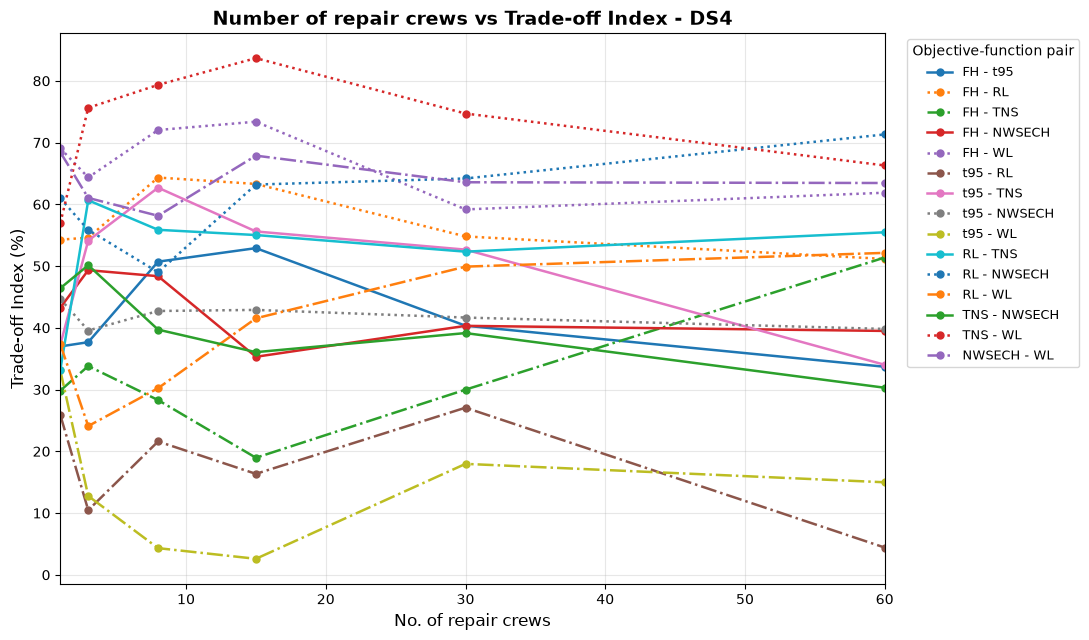

In [ ]:
# PLOT

fig, ax = plt.subplots(figsize=(11, 6.5))

# Different line styles
line_styles = ["-", ":", "-."]

for i, pair in enumerate(selected_pairs):

    ax.plot(
        toi_df["Crews"],
        toi_df[pair],
        marker="o",
        linewidth=1.8,
        markersize=5,
        linestyle=line_styles[i % len(line_styles)],
        label=pair
    )

# ------------------------------------------------------------
# Axis labels
# ------------------------------------------------------------

ax.set_xlabel("No. of repair crews", fontsize=12)
ax.set_ylabel("Trade-off Index (%)", fontsize=12)

# ------------------------------------------------------------
# Title
# ------------------------------------------------------------

ax.set_title(
    f"Number of repair crews vs Trade-off Index - {ds_sel}",
    fontsize=14,
    fontweight="bold"
)

# ------------------------------------------------------------
# X-axis
# ------------------------------------------------------------

ax.set_xlim(
    toi_df["Crews"].min(),
    toi_df["Crews"].max()
)

# ------------------------------------------------------------
# Grid
# ------------------------------------------------------------

ax.grid(True, alpha=0.3)

# ------------------------------------------------------------
# Legend
# ------------------------------------------------------------

ax.legend(
    title="Objective-function pair",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=9
)

plt.tight_layout()

plt.show()

## 7. Optional: save the figure

In [ ]:
# SAVE FIGURE

output_file = f"crews_vs_tradeoff_index_{ds_sel}.png"

fig.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

print(f"Figure saved as: {output_file}")


Figure saved as: crews_vs_tradeoff_index_DS4.png
